<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/lab1/mldl_lab_1_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
n_samples = 100
hours_studied = np.random.uniform(2, 20, n_samples)
attendance = np.random.uniform(60, 100, n_samples)
# Score is influenced by hours and attendance with some random noise
final_score = (hours_studied * 3) + (attendance * 0.3) + np.random.normal(0, 5, n_samples)
# Clip scores to be between 0 and 100
final_score = np.clip(final_score, 0, 100)

data = {
    'Student_ID': range(1, n_samples + 1),
    'Hours_Studied': np.round(hours_studied, 1),
    'Attendance': np.round(attendance, 1),
    'Final_Score': np.round(final_score, 1)
}

df_synthetic = pd.DataFrame(data)
df_synthetic.to_csv('student_performance.csv', index=False)
print("File 'student_performance.csv' has been generated successfully.")

File 'student_performance.csv' has been generated successfully.


In [2]:
# Exercise 1: NumPy Basics
df = pd.read_csv('student_performance.csv')
print("--- Exercise 1: NumPy Basics ---")

# 1. Load Final_Score as NumPy array
final_scores = df['Final_Score'].to_numpy()

# 2. Compute mean, median, and standard deviation
mean_val = np.mean(final_scores)
median_val = np.median(final_scores)
std_val = np.std(final_scores)

print(f"Mean Final Score: {mean_val:.2f}")
print(f"Median Final Score: {median_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

# 3. Perform Min-Max normalization
min_val = np.min(final_scores)
max_val = np.max(final_scores)
normalized_scores = (final_scores - min_val) / (max_val - min_val)

print("Normalized Scores (first 5):", np.round(normalized_scores[:5], 2))

--- Exercise 1: NumPy Basics ---
Mean Final Score: 55.90
Median Final Score: 54.25
Standard Deviation: 16.71
Normalized Scores (first 5): [0.23 0.87 0.64 0.49 0.4 ]


In [3]:
# Exercise 2: Pandas Data Handling
print("--- Exercise 2: Pandas Data Handling ---")

# 1. Check shape and missing values
print(f"Shape of dataset: {df.shape}")
print("Missing Values:\n", df.isnull().sum())

# 2. Create Performance label
def classify_performance(score):
    if score >= 75:
        return 'Good'
    elif score >= 60:
        return 'Average'
    else:
        return 'Low'

df['Performance'] = df['Final_Score'].apply(classify_performance)
print("\nData with Performance Label (first 5 rows):")
print(df[['Final_Score', 'Performance']].head())

--- Exercise 2: Pandas Data Handling ---
Shape of dataset: (100, 4)
Missing Values:
 Student_ID       0
Hours_Studied    0
Attendance       0
Final_Score      0
dtype: int64

Data with Performance Label (first 5 rows):
   Final_Score Performance
0         41.2         Low
1         84.1        Good
2         68.8     Average
3         58.9         Low
4         52.6         Low


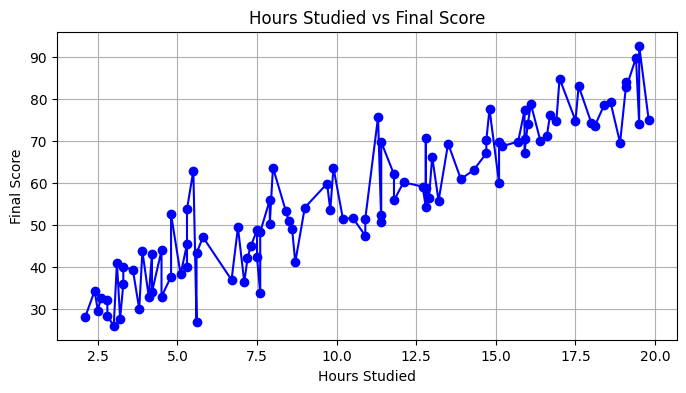

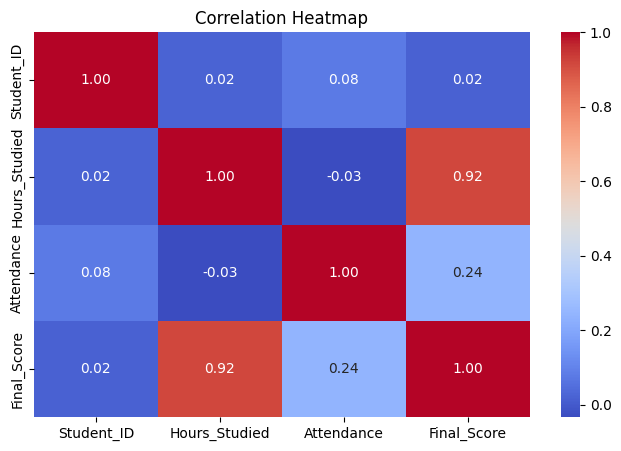

/tmp/ipykernel_358/324745291.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Performance', y='Final_Score', order=['Low', 'Average', 'Good'], palette='Set2')


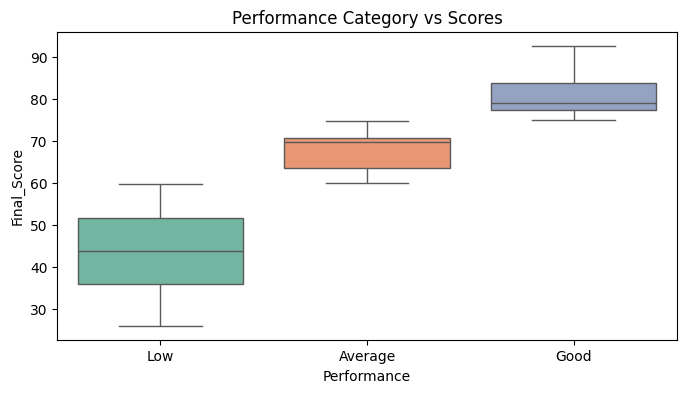

In [4]:
# Exercise 3 & 4: Visualization

# 1. Line plot: Hours vs Score
df_sorted = df.sort_values(by='Hours_Studied')
plt.figure(figsize=(8, 4))
plt.plot(df_sorted['Hours_Studied'], df_sorted['Final_Score'], marker='o', color='blue')
plt.title('Hours Studied vs Final Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.grid(True)
plt.show()

# 2. Seaborn Heatmap
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 3. Boxplot: Performance vs Final Score
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Performance', y='Final_Score', order=['Low', 'Average', 'Good'], palette='Set2')
plt.title('Performance Category vs Scores')
plt.show()